In [38]:
# Importar bibliotecas

import pandas as pd 
import seaborn as sns
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure
from matplotlib.colors import LinearSegmentedColormap

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8) # Ajustando a configuração dos plots sendo criados

# Ler os dados

df = pd.read_csv(r'Steel_industry_data.csv')

In [39]:
# Primeiro vislumbre nos dados

df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [40]:
# Procurando se existem valores vazios em alguma coluna

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, pct_missing))

date - 0.0%
Usage_kWh - 0.0%
Lagging_Current_Reactive.Power_kVarh - 0.0%
Leading_Current_Reactive_Power_kVarh - 0.0%
CO2(tCO2) - 0.0%
Lagging_Current_Power_Factor - 0.0%
Leading_Current_Power_Factor - 0.0%
NSM - 0.0%
WeekStatus - 0.0%
Day_of_week - 0.0%
Load_Type - 0.0%


In [41]:
# Tipos de dados por colunas

df.dtypes

date                                        str
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                                  str
Day_of_week                                 str
Load_Type                                   str
dtype: object

In [42]:
# Renomeando as colunas para facilitar a escrita do código

df = df.rename(columns={
    'date': 'Data',
    'Usage_kWh': 'Uso_kWh',
    'Lagging_Current_Reactive.Power_kVarh': 'Reativa_Lag',
    'Leading_Current_Reactive_Power_kVarh': 'Reativa_Lead',
    'CO2(tCO2)': 'CO2',
    'Lagging_Current_Power_Factor': 'Fator_Lag',
    'Leading_Current_Power_Factor': 'Fator_Lead',
    'NSM': 'Segundos_Meia_Noite',
    'WeekStatus': 'Status_Semana',
    'Day_of_week': 'Dia_Semana',
    'Load_Type': 'Tipo_Carga'
})

# Visualizar
df.head()

,Data,Uso_kWh,Reativa_Lag,Reativa_Lead,CO2,Fator_Lag,Fator_Lead,Segundos_Meia_Noite,Status_Semana,Dia_Semana,Tipo_Carga
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [43]:
# Criando uma coluna de 'Hora' para facilitar análise 

# Fazendo com que a coluna 'Data' seja reconhecida como Tempo/Data em formato DMY
df['Data'] = pd.to_datetime(df['Data'], format='%d/%m/%Y %H:%M')

# Dividindo Hora e Data separadamente
df['Hora'] = df['Data'].dt.time 
df['Data'] = df['Data'].dt.date 

# Reorganizando a ordem para que 'Hora' fique logo após 'Data'
colunas_atuais = df.columns.tolist()
colunas_atuais.remove('Hora')
colunas_atuais.insert(1, 'Hora')
df = df[colunas_atuais]

# Arredondando os números para 2 casas decimais
colunas_numericas = df.select_dtypes(include=['number']).columns
df[colunas_numericas] = df[colunas_numericas].round(2)

# Visualizar
df.head()

,Data,Hora,Uso_kWh,Reativa_Lag,Reativa_Lead,CO2,Fator_Lag,Fator_Lead,Segundos_Meia_Noite,Status_Semana,Dia_Semana,Tipo_Carga
0,2018-01-01,00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,2018-01-01,00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,2018-01-01,00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,2018-01-01,01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,2018-01-01,01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [68]:
df.head()

,Data,Hora,Uso_kWh,Reativa_Lag,Reativa_Lead,CO2,Fator_Lag,Fator_Lead,Segundos_Meia_Noite,Status_Semana,Dia_Semana,Tipo_Carga,Tipo_Carga_Num,Hora_Int
0,2018-01-01,00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,1,0
1,2018-01-01,00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,1,0
2,2018-01-01,00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,1,0
3,2018-01-01,01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,1
4,2018-01-01,01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,1


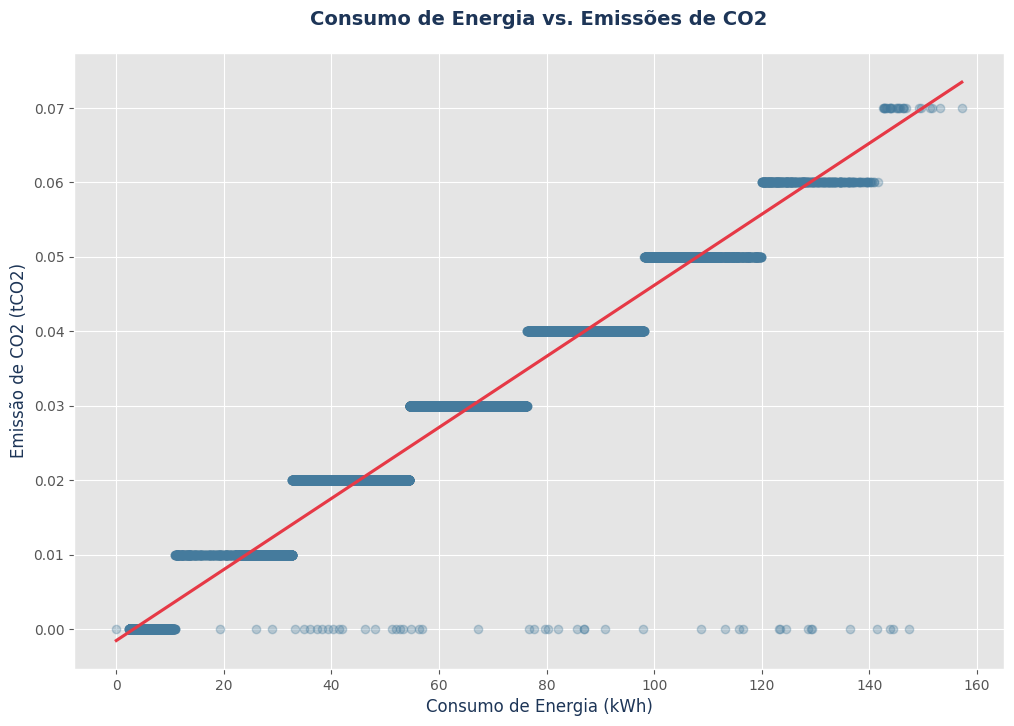

In [45]:
# Verificando se o CO2 sobe de forma proporcional ao Uso_kWh
# Criar o Scatter Plot com linha de tendência

sns.regplot(
    x='Uso_kWh',
    y='CO2',
    data=df,
    scatter_kws={"color": "#457b9d", "alpha": 0.3},
    line_kws={"color": "#e63946"}
)

plt.title(
    'Consumo de Energia vs. Emissões de CO2', 
    fontsize=14,
    pad=20,
    fontweight='bold',
    color='#1d3557'
    )
plt.xlabel('Consumo de Energia (kWh)', fontsize=12, color='#1d3557')
plt.ylabel('Emissão de CO2 (tCO2)', fontsize=12, color='#1d3557')

plt.show()

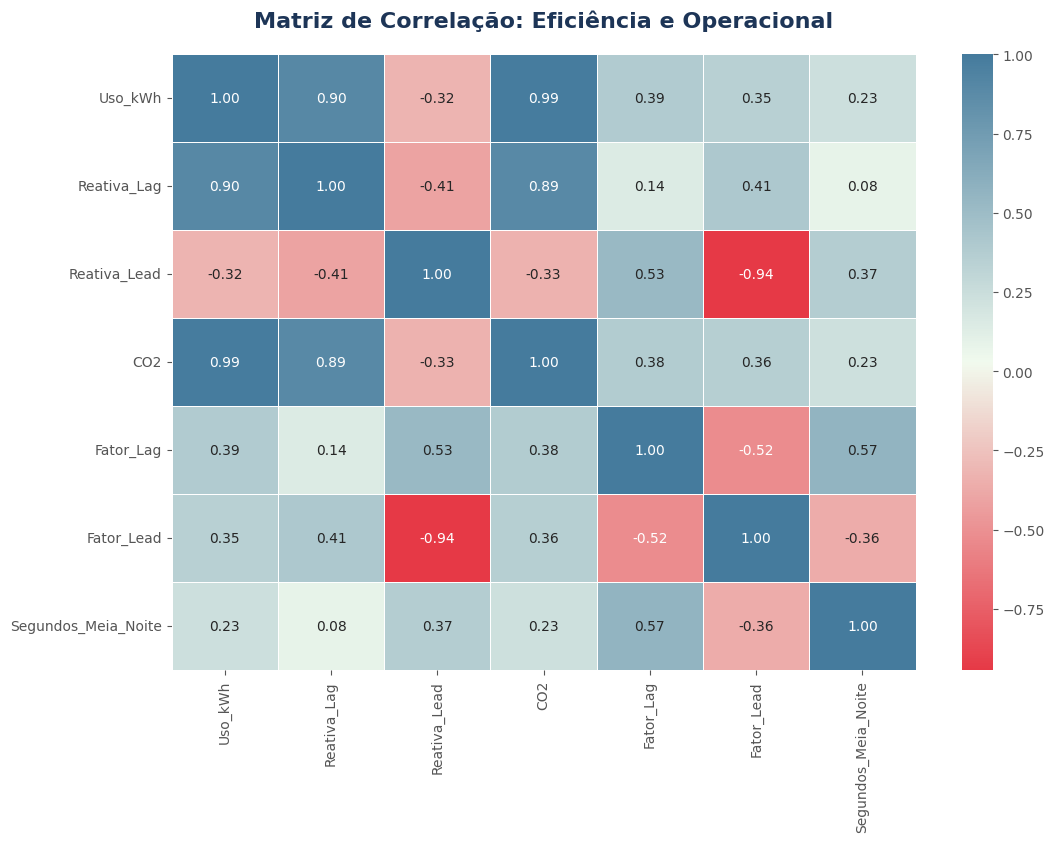

In [51]:
# Início da Correlação

# Criando padrão de cores que respeitem minha paleta específica do projeto
minhas_cores = ["#e63946","#f1faee","#457b9d"]
meu_degrade = LinearSegmentedColormap.from_list("DegradeLucas", minhas_cores)

# --- Criando o Heatmap ---

# Separando colunas com números apenas
df_numerico = df.select_dtypes(include=['float64', 'int64'])
matriz_correlacao = df_numerico.corr(method='pearson')

# Configurando o heatmap
sns.heatmap(matriz_correlacao, annot=True, cmap=meu_degrade, fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação: Eficiência e Operacional', fontsize=16, pad=20, fontweight='bold', color='#1d3557')

plt.show()

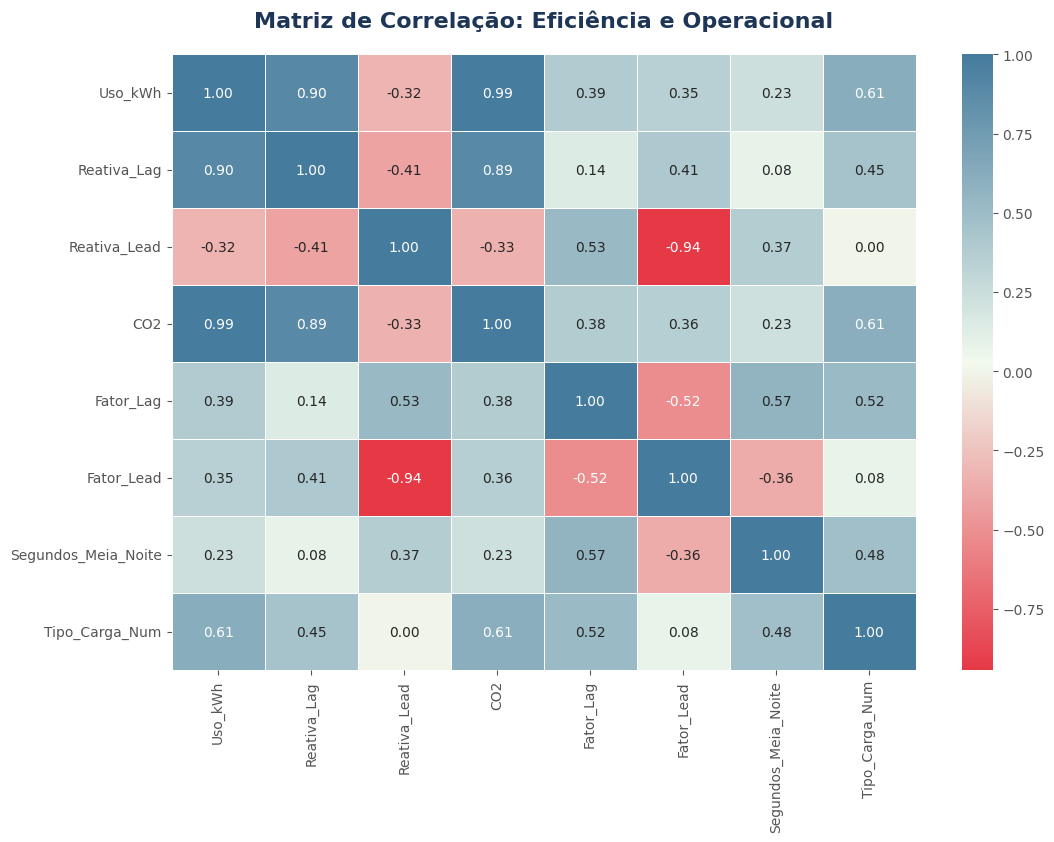

In [53]:
# Conforme a carga da fábrica sobe o nível, o consumo de energia aumenta junto?

# Mapeamento Ordinal
# Light_Load (Carga Leve) = 1 (Menor)
# Medium_Load (Carga Média) = 2
# Maximum_Load (Carga Máxima) = 3 (Maior)

mapa_carga_ordinal = {'Light_Load': 1, 'Medium_Load': 2, 'Maximum_Load': 3}
df['Tipo_Carga_Num'] = df['Tipo_Carga'].map(mapa_carga_ordinal)

# Adicionando a nova coluna ao Heatmap

# --- Início da Correlação ---

# Criando padrão de cores que respeitem minha paleta específica do projeto
minhas_cores = ["#e63946","#f1faee","#457b9d"]
meu_degrade = LinearSegmentedColormap.from_list("DegradeLucas", minhas_cores)

# --- Criando o Heatmap ---

# Separando colunas com números apenas
df_numerico = df.select_dtypes(include=['float64', 'int64'])
matriz_correlacao = df_numerico.corr(method='pearson')

# Configurando o heatmap
sns.heatmap(matriz_correlacao, annot=True, cmap=meu_degrade, fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação: Eficiência e Operacional', fontsize=16, pad=20, fontweight='bold', color='#1d3557')

plt.show()

In [63]:
# Tabela direta para correlação

# Máscara para diminuir repetições
mascara = np.triu(np.ones_like(matriz_correlacao, dtype=bool), k=1)
matriz_limpa = matriz_correlacao.where(mascara)

# Formando a lista
pares = matriz_limpa.unstack().reset_index()
pares.columns = ['Variável 1', 'Variável 2', 'Correlação']
pares = pares.dropna()

# Filtro de correlações fortes
fortes = pares[(pares['Correlação'] > 0.5) | (pares['Correlação'] < -0.5)]
fortes = fortes.sort_values(by='Correlação', ascending=False)

# Criando uma tabela estilizada 
tabela_correlacao = fortes.style.background_gradient(cmap=meu_degrade, subset=['Correlação']) \
                          .format({'Correlação': '{:.2f}'}) \
                          .hide(axis='index')

tabela_correlacao

Variável 1,Variável 2,Correlação
CO2,Uso_kWh,0.99
Reativa_Lag,Uso_kWh,0.90
CO2,Reativa_Lag,0.89
Tipo_Carga_Num,Uso_kWh,0.61
Tipo_Carga_Num,CO2,0.61
Segundos_Meia_Noite,Fator_Lag,0.57
Fator_Lag,Reativa_Lead,0.53
Tipo_Carga_Num,Fator_Lag,0.52
Fator_Lead,Fator_Lag,-0.52
Fator_Lead,Reativa_Lead,-0.94


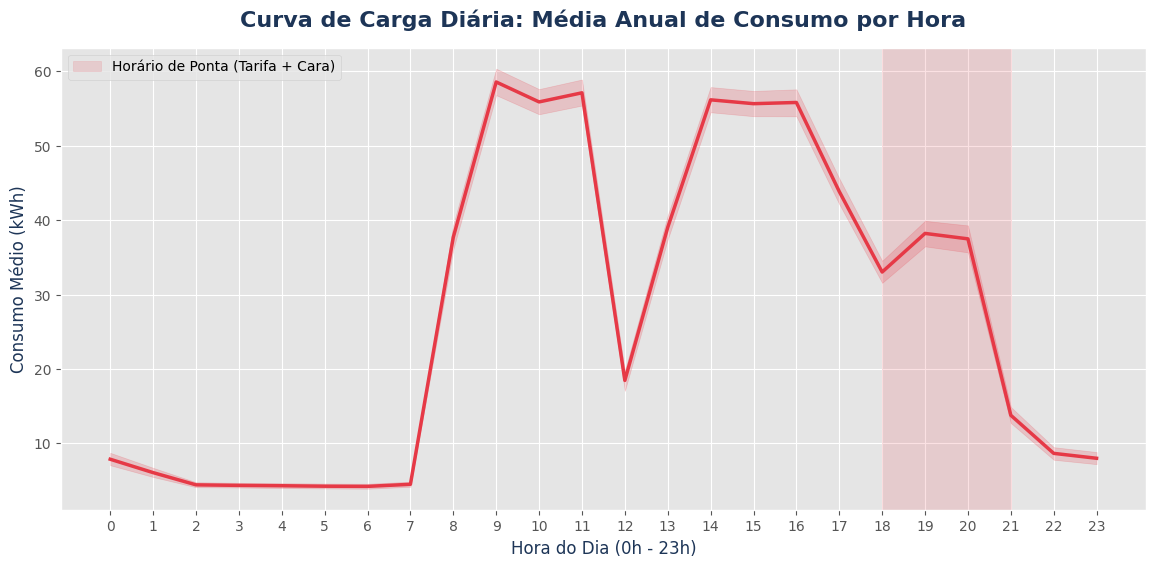

In [67]:
# A que horas a fábrica atinge o seu pico de consumo?

# Extraindo só o número da hora (0 a 23) para que o eixo x fique limpo
df['Hora_Int'] = df['Hora'].apply(lambda x: x.hour)

# ---
plt.figure(figsize=(14, 6))

# lineplot pra calcular a média de todos os dias do ano para cada hora
sns.lineplot(data=df, x='Hora_Int', y='Uso_kWh', color='#e63946', linewidth=2.5)

# gráfico
plt.axvspan(18, 21, color='#e63946', alpha=0.15, label='Horário de Ponta (Tarifa + Cara)')
plt.title('Curva de Carga Diária: Média Anual de Consumo por Hora', fontsize=16, fontweight='bold', pad=15, color='#1d3557')
plt.xlabel('Hora do Dia (0h - 23h)', fontsize=12, color='#1d3557')
plt.ylabel('Consumo Médio (kWh)', fontsize=12, color='#1d3557')
plt.xticks(range(0, 24))
plt.legend()

plt.show()

🚨 RELATÓRIO DE RISCO DE MULTA (ENERGIA REATIVA) 🚨
Total de medições no ano (15 em 15 min): 35040
Medições com Fator de Potência ABAIXO de 92%: 21166
A fábrica operou em RISCO DE MULTA em 60.41% do tempo analisado!


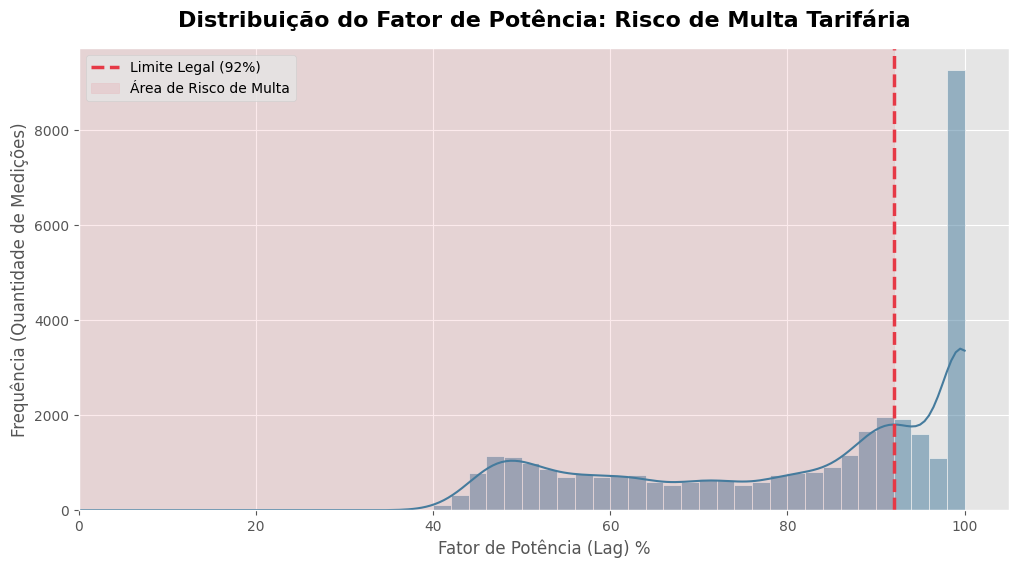

In [71]:
# --- Quantas vezes a fábrica operou com risco de ser multada pela concessionária de energia? ---

# Histograma com linha máxima de perigo

limite_seguranca = 92.0
alertas_multa = df[df['Fator_Lag'] < limite_seguranca]
total_alertas = len(alertas_multa)
total_registros = len(df)

porcentagem_risco = (total_alertas / total_registros) * 100

# Relatório
print("="*50)
print("🚨 RELATÓRIO DE RISCO DE MULTA (ENERGIA REATIVA) 🚨")
print("="*50)
print(f"Total de medições no ano (15 em 15 min): {total_registros}")
print(f"Medições com Fator de Potência ABAIXO de 92%: {total_alertas}")
print(f"A fábrica operou em RISCO DE MULTA em {porcentagem_risco:.2f}% do tempo analisado!")
print("="*50)

# Gráfico
plt.figure(figsize=(12, 6))

sns.histplot(df['Fator_Lag'], bins=50, color='#457b9d', kde=True)
plt.axvline(limite_seguranca, color='#e63946', linestyle='dashed', linewidth=2.5, label='Limite Legal (92%)')
plt.axvspan(0, limite_seguranca, color='#e63946', alpha=0.1, label='Área de Risco de Multa')
plt.title('Distribuição do Fator de Potência: Risco de Multa Tarifária', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Fator de Potência (Lag) %', fontsize=12)
plt.ylabel('Frequência (Quantidade de Medições)', fontsize=12)
plt.xlim(0, 105)
plt.legend()
    
plt.show()